# Model creation

author: @Embra-Schuilenburg

COMP 432: Main Project

This document will define functions, classes, and scripts for the models that will be used later in this project. Models that will be created include:

- 1D single-task CNNs
- 1D multi-task CNNs
- ? feature extractor setup

For each model this notebook will:
- Define the basic structure of the model if a (sufficient prexisting implementation doesn't exist)
- Define any needed training, validation, or direct solution methods
- Implement performance monitoring, optimization, and hyperparameter tuning methods (although no optimization or tuning will be performed in this notebook)

Models will be constructed as general models with specifiable parameters that can be adjusted by experiment. Referring to the model as 'general' is to say that numerous data embedding strategies may be experimented with; as finding the ideal fMRI encoding is a very important factor in the success of any model used on it. As such, models should be able to process any data of a similar modality even if it's dimensions aren't identical.

## Imports and packages

In [67]:
from helper_functions import load_saved_run
import importnb
import random
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [68]:
# Set seeds for reproducability of tests

def set_seed(seed=67):
    # Python
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)

    # NumPy
    np.random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Deterministic behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Stricter determinism
    torch.use_deterministic_algorithms(True)


SEED = 67
set_seed(SEED)

---

# 1D single-task CNNs

**Overview**
In this section the report will outline and then construct the framework for a general single signal predicting 1D CNNs that will be used later in this project. 

**I/O details**
Expected inputs: one run of ROIs averaged over a window for each sequnce (*see figure below*)
Input shape: num_rois, seq_len (100, 60)
Target shape: 1, seq_len (1, 60) vector of scalers

**Hyperparameters**:
- Input channels = 1
- Output channnels = 1
- Kernel size = 100x3
- Padding = one zero on each end
- Stride length = 0

Expected inputs:
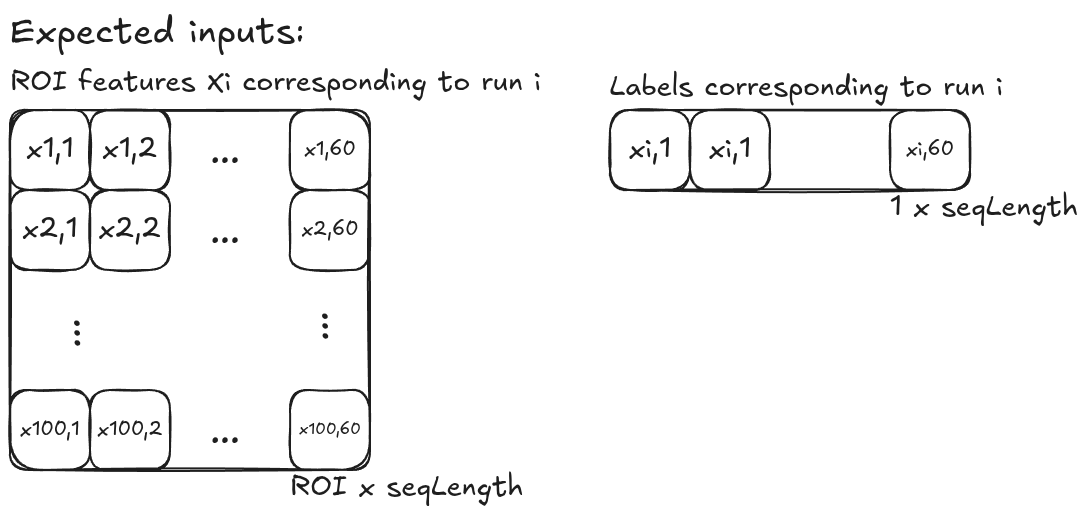

## Data loading, splitting, and normalization functions

Runs will be collected from the processed-data folder as was specified in `1-data-preprocessing.ipynb`. 

Please note two important fact regarding the data:

1. It is essential that although a run is considered a single input, splitting is performed by participant. This is essential because should inputs be split by row, there would be the possibility of data leakage in which the model is evaluated on data from a participant it was trained on. 
2. Normalization of features and of signal labels is not required as they have been normalized already. ROI features were normalized during preprocessing, and label values were normalized during data collection.
    - No global normalization was performed, ROIs were normalized within each run and labels were normalized by subject


In [69]:
# Data collection method

def collect_run_records(output_dir):
    """
    Find all saved run-level npz files and return records.

    Expected structure:
        output_dir/
            sub-01/
                run-1/
                    features_and_labels.npz
                    trial_metadata.csv
    """
    output_dir = Path(output_dir)
    npz_paths = sorted(output_dir.glob('sub-*/run-*/features_and_labels.npz'))

    if len(npz_paths) == 0:
        raise FileNotFoundError(f'No run files found under: {output_dir}')

    records = []
    for npz_path in npz_paths:
        subject_id = npz_path.parent.parent.name
        run_id = npz_path.parent.name

        records.append({
            'subject_id': subject_id,
            'run_id': run_id,
            'npz_path': npz_path
        })

    return records


# Data splitting method

def split_records_by_subject(records, train_frac=0.70, val_frac=0.15, test_frac=0.15, seed=67):
    """
    Split at the subject level to avoid leakage. 
    Splits should be passed as decimals between 0.0 and 1.0 and should sum to 1.
    All runs from a subject stay in exactly one split.
    """
    subjects = sorted({rec['subject_id'] for rec in records})
    n_subjects = len(subjects)
    rng = np.random.default_rng(seed)
    rng.shuffle(subjects)

    n_test = max(1, int(round(test_frac * n_subjects)))
    n_val = max(1, int(round(val_frac * n_subjects)))
    n_train = n_subjects - n_val - n_test

    train_subjects = set(subjects[:n_train])
    val_subjects = set(subjects[n_train:n_train + n_val])
    test_subjects = set(subjects[n_train + n_val:])

    train_records = [r for r in records if r['subject_id'] in train_subjects]
    val_records = [r for r in records if r['subject_id'] in val_subjects]
    test_records = [r for r in records if r['subject_id'] in test_subjects]

    return train_records, val_records, test_records


# Data set

class RunSequenceDataset(Dataset):
    """
    One item = one run.

    Returns:
        x       : [n_trials, n_rois]
        y       : [n_trials]       (single-task target sequence)
        length  : int
    """

    def __init__(self, records, target_name='surprise'):
        self.records = records
        self.target_name = target_name

        if target_name not in {'surprise', 'V'}:
            raise ValueError('target_name must be "surprise" or "V"')

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        X, _, y_surprise, y_V, roi_names, y_names = load_saved_run(
            rec['npz_path'])

        X = X.astype(np.float32)

        if self.target_name == 'surprise':
            y = y_surprise.astype(np.float32)
        else:
            y = y_V.astype(np.float32)

        # TODO: update graphic to match dataloader instance dimensions (transpose)
        item = {
            'x': torch.from_numpy(X),   # [n_trials, n_rois]
            'y': torch.from_numpy(y)   # [n_trials]
        }

        return item

## Single-task 1D CNN

This CNN class will define the model that will be single task prediction. The model will be a sequence-to-sequence model and convole over the trials. For each trial, a predicted RL signal will be output. 

In [70]:
# TODO: plan where hyperparameter tuning should be placed
# TODO: maybe add W&B hyperparameter tracking to later tuning
# Single-task CNN class

class SingleTask1DCNN(nn.Module):
    """
    CNN for single-task regression on run sequences.

    Input:
        x: [B, T, R]
            B = batch size
            T = number of trials
            R = number of ROIs

    Output:
        y_pred: [B, T]
            One scalar prediction per trial
    """

    def __init__(
        self,
        n_rois,
        hidden_channels=32,
        kernel_size=3,
        dropout=.1
    ):
        super().__init__()

        if kernel_size % 2 == 0:
            raise ValueError(
                "kernel_size should be odd so same-length padding is simple.")

        padding = kernel_size // 2

        self.feature_extractor = nn.Sequential(
            nn.Conv1d(
                in_channels=n_rois,
                out_channels=hidden_channels,
                kernel_size=kernel_size,
                padding=padding
            ),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(
                in_channels=hidden_channels,
                out_channels=hidden_channels,
                kernel_size=kernel_size,
                padding=padding
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.head = nn.Conv1d(
            in_channels=hidden_channels,
            out_channels=1,
            kernel_size=1
        )

    def forward(self, x):
        x = x.transpose(1, 2)      # [B, R, T]

        x = self.feature_extractor(x)

        x = self.head(x)           # [B, 1, T]
        x = x.squeeze(1)           # [B, T]
        return x

In [71]:
# # Testing scratch-block

# batch = next(iter(train_loader))

# x = batch['x']   # [B, T, R]
# print("input shape:", x.shape)

# model = SingleTask1DCNN(
#     n_rois=x.shape[-1],
#     hidden_channels=32,
#     kernel_size=3
# )

# y_pred = model(x)
# print("output shape:", y_pred.shape)
# print("target shape:", batch['y'].shape)

## Training and eval functions

In [72]:
# Training and test/val epochs

def train_epoch(model, dataloader, optimizer, criterion, device):
    """
    Run one training epoch and return mean batch loss.
    """
    model.train()
    total_loss = 0.0
    n_batches = 0

    for batch in dataloader:
        x = batch['x'].to(device)   # [B, T, R]
        y = batch['y'].to(device)   # [B, T]

        optimizer.zero_grad()

        y_pred = model(x)           # [B, T]
        loss = criterion(y_pred, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    mean_loss = total_loss / n_batches
    return mean_loss


def val_epoch(model, dataloader, criterion, device):
    """
    Run evaluation and return mean batch loss.
    """
    model.eval()
    total_loss = 0.0
    n_batches = 0

    with torch.no_grad():
        for batch in dataloader:
            x = batch['x'].to(device)   # [B, T, R]
            y = batch['y'].to(device)   # [B, T]

            y_pred = model(x)
            loss = criterion(y_pred, y)

            total_loss += loss.item()
            n_batches += 1

    mean_loss = total_loss / n_batches
    return mean_loss

In [73]:
# TODO: consider adding an early stopping mechanism
# Model training loop

# Model training loop

def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=20):
    """
    Full training loop.
    Returns a history dictionary.
    """
    history = {
        'train_loss': [],
        'val_loss': []
    }

    for epoch in range(epochs):
        train_loss = train_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device
        )

        val_loss = val_epoch(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            device=device
        )

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        print(
            f"Epoch {epoch + 1:02d}/{epochs:02d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f}"
        )

    return history

In [74]:
# Testing scratch-block

records = collect_run_records('processed_data')
records

train, val, test = split_records_by_subject(
    records=records, train_frac=.8, val_frac=.1, test_frac=.1)

print(len(train),
      len(val),
      len(test)
      )

target = 'surprise'

batch_size = 16

train_dataset = RunSequenceDataset(
    train,
    target_name=target
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_dataset = RunSequenceDataset(
    val,
    target_name=target
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_dataset = RunSequenceDataset(
    test,
    target_name=target
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

276 36 36


In [79]:
# Testing scratch-block

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

sample_batch = next(iter(train_loader))
n_rois = sample_batch['x'].shape[-1]

model = SingleTask1DCNN(
    n_rois=n_rois,
    hidden_channels=8,
    kernel_size=5,
    dropout=.3
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 30

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=epochs
)

test_loss = val_epoch(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

print(f"Test loss: {test_loss:.4f}")

Epoch 01/30 | train_loss=1.0234 | val_loss=1.0052
Epoch 02/30 | train_loss=1.0072 | val_loss=0.9992
Epoch 03/30 | train_loss=0.9971 | val_loss=0.9931
Epoch 04/30 | train_loss=0.9953 | val_loss=0.9921
Epoch 05/30 | train_loss=0.9904 | val_loss=0.9912
Epoch 06/30 | train_loss=0.9889 | val_loss=0.9920
Epoch 07/30 | train_loss=0.9821 | val_loss=0.9933
Epoch 08/30 | train_loss=0.9766 | val_loss=0.9926
Epoch 09/30 | train_loss=0.9775 | val_loss=0.9916
Epoch 10/30 | train_loss=0.9721 | val_loss=0.9918
Epoch 11/30 | train_loss=0.9716 | val_loss=0.9901
Epoch 12/30 | train_loss=0.9630 | val_loss=0.9886
Epoch 13/30 | train_loss=0.9656 | val_loss=0.9928
Epoch 14/30 | train_loss=0.9573 | val_loss=0.9960
Epoch 15/30 | train_loss=0.9547 | val_loss=0.9976
Epoch 16/30 | train_loss=0.9489 | val_loss=0.9985
Epoch 17/30 | train_loss=0.9500 | val_loss=0.9977
Epoch 18/30 | train_loss=0.9486 | val_loss=1.0011
Epoch 19/30 | train_loss=0.9490 | val_loss=1.0010
Epoch 20/30 | train_loss=0.9413 | val_loss=1.0006


In [80]:
def zero_baseline_mse(dataloader):
    total = 0.0
    n_batches = 0

    for batch in dataloader:
        y = batch['y']
        y_pred = torch.zeros_like(y)
        loss = nn.functional.mse_loss(y_pred, y)
        total += loss.item()
        n_batches += 1

    return total / n_batches


print("Zero baseline train:", zero_baseline_mse(train_loader))
print("Zero baseline val:", zero_baseline_mse(val_loader))
print("Zero baseline test:", zero_baseline_mse(test_loader))

Zero baseline train: 1.0000000099341075
Zero baseline val: 1.0000000794728596
Zero baseline test: 1.00000003973643


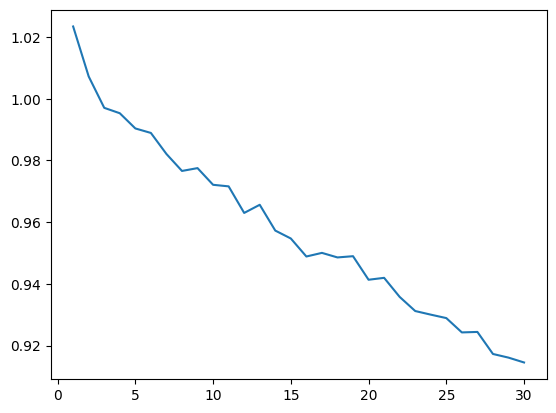

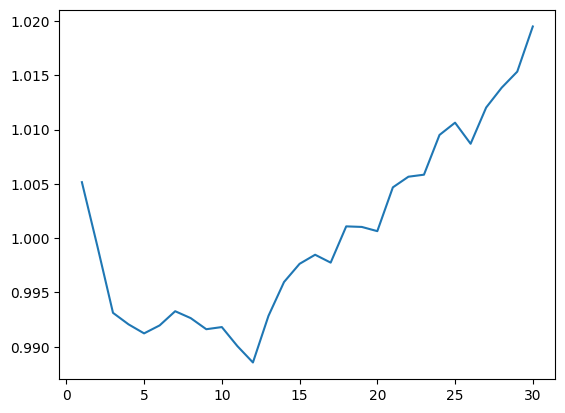

In [81]:
train_loss = np.array(history['train_loss'])
plt.figure()
plt.plot(range(1, epochs+1), train_loss)
plt.figure()
plt.plot(range(1, epochs+1), history['val_loss'])

## Testing

# 1D multi-task CNNs

# Linear models

# Multi-task ElasticNet models